In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from networkx.algorithms.community import quality
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import minmax_scale


In [101]:

spect = np.load('spectrums.npy')
labels = pd.read_csv('FM_Parameter_Table.csv')
auxill = pd.read_csv('AuxillaryTable.csv')

wavelengths = spect[ 0, :, 0]
spectrum = spect[:, :, 1]

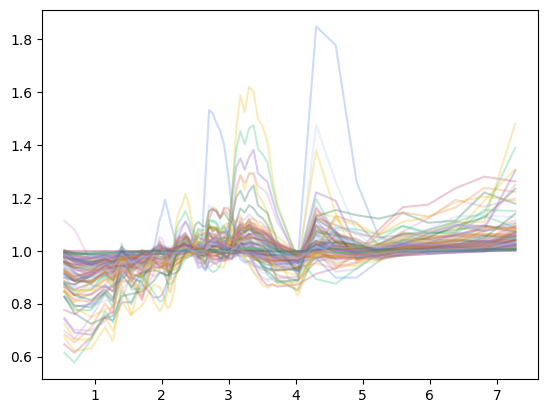

In [102]:
for i in np.random.choice(len(spectrum), 100):
  plt.plot(wavelengths, spectrum[i]/np.median(spectrum[i]), alpha=0.3)



In [131]:
labels.columns

Index(['Unnamed: 0', 'planet_ID', 'planet_radius', 'planet_temp', 'log_H2O',
       'log_CO2', 'log_CO', 'log_CH4', 'log_NH3'],
      dtype='object')

In [142]:
param_names = ['planet_radius', 'planet_temp', 'log_H2O',
       'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']

output = labels[param_names].values

In [133]:
y_norm = minmax_scale(output)
# X_norm = spectrum/1
norm_koeffs = np.median(spectrum, axis=1).reshape(-1,1)
X_norm = spectrum/np.median(spectrum, axis=1).reshape(-1,1)

X_norm = np.concatenate((X_norm, norm_koeffs), axis=1)



spectrum.shape

(41423, 52)

In [134]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.1, random_state=1)
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=1)

In [135]:
n = output.shape[1]
model = tf.keras.Sequential([tf.keras.Input(shape=(53,)),
tf.keras.layers.Dense(200, activation='relu'),
tf.keras.layers.Dense(100, activation='relu'),
tf.keras.layers.Dense(50, activation='relu'),
tf.keras.layers.Dense(n)
])


model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])


In [136]:
history = model.fit(X_train, y_train, validation_data = (X_test, y_test),
          epochs=50, shuffle=True,
          batch_size=200)

Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0639 - mae: 0.1957 - val_loss: 0.0532 - val_mae: 0.1836
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0545 - mae: 0.1776 - val_loss: 0.0471 - val_mae: 0.1715
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0451 - mae: 0.1651 - val_loss: 0.0409 - val_mae: 0.1574
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0388 - mae: 0.1523 - val_loss: 0.0352 - val_mae: 0.1445
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0353 - mae: 0.1432 - val_loss: 0.0340 - val_mae: 0.1422
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0325 - mae: 0.1360 - val_loss: 0.0315 - val_mae: 0.1325
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0304 - mae: 0.1302 - val_loss: 0.0353 - val_mae: 0.1420
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0292 - mae: 0.1266 - val_loss: 0.0284 - val_mae: 0.1260
Epoch 9/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

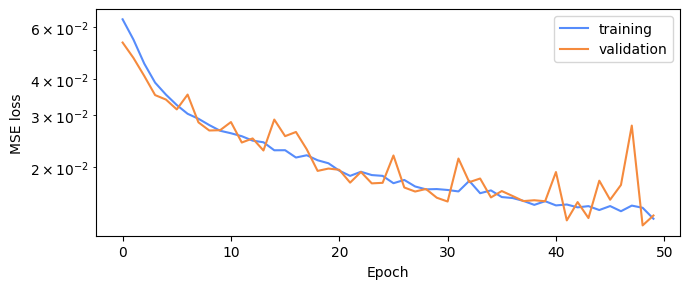

In [137]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(training_loss, label='training')
ax.plot(validation_loss, label='validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

In [138]:

y_pred = model.predict(X_test)


130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step


In [139]:
loss, accuracy  = model.evaluate(X_test, y_test)

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 0.0137 - mae: 0.0775


In [144]:
quality = np.sum((y_pred-y_test)**2, axis=0)/y_test.shape[0]

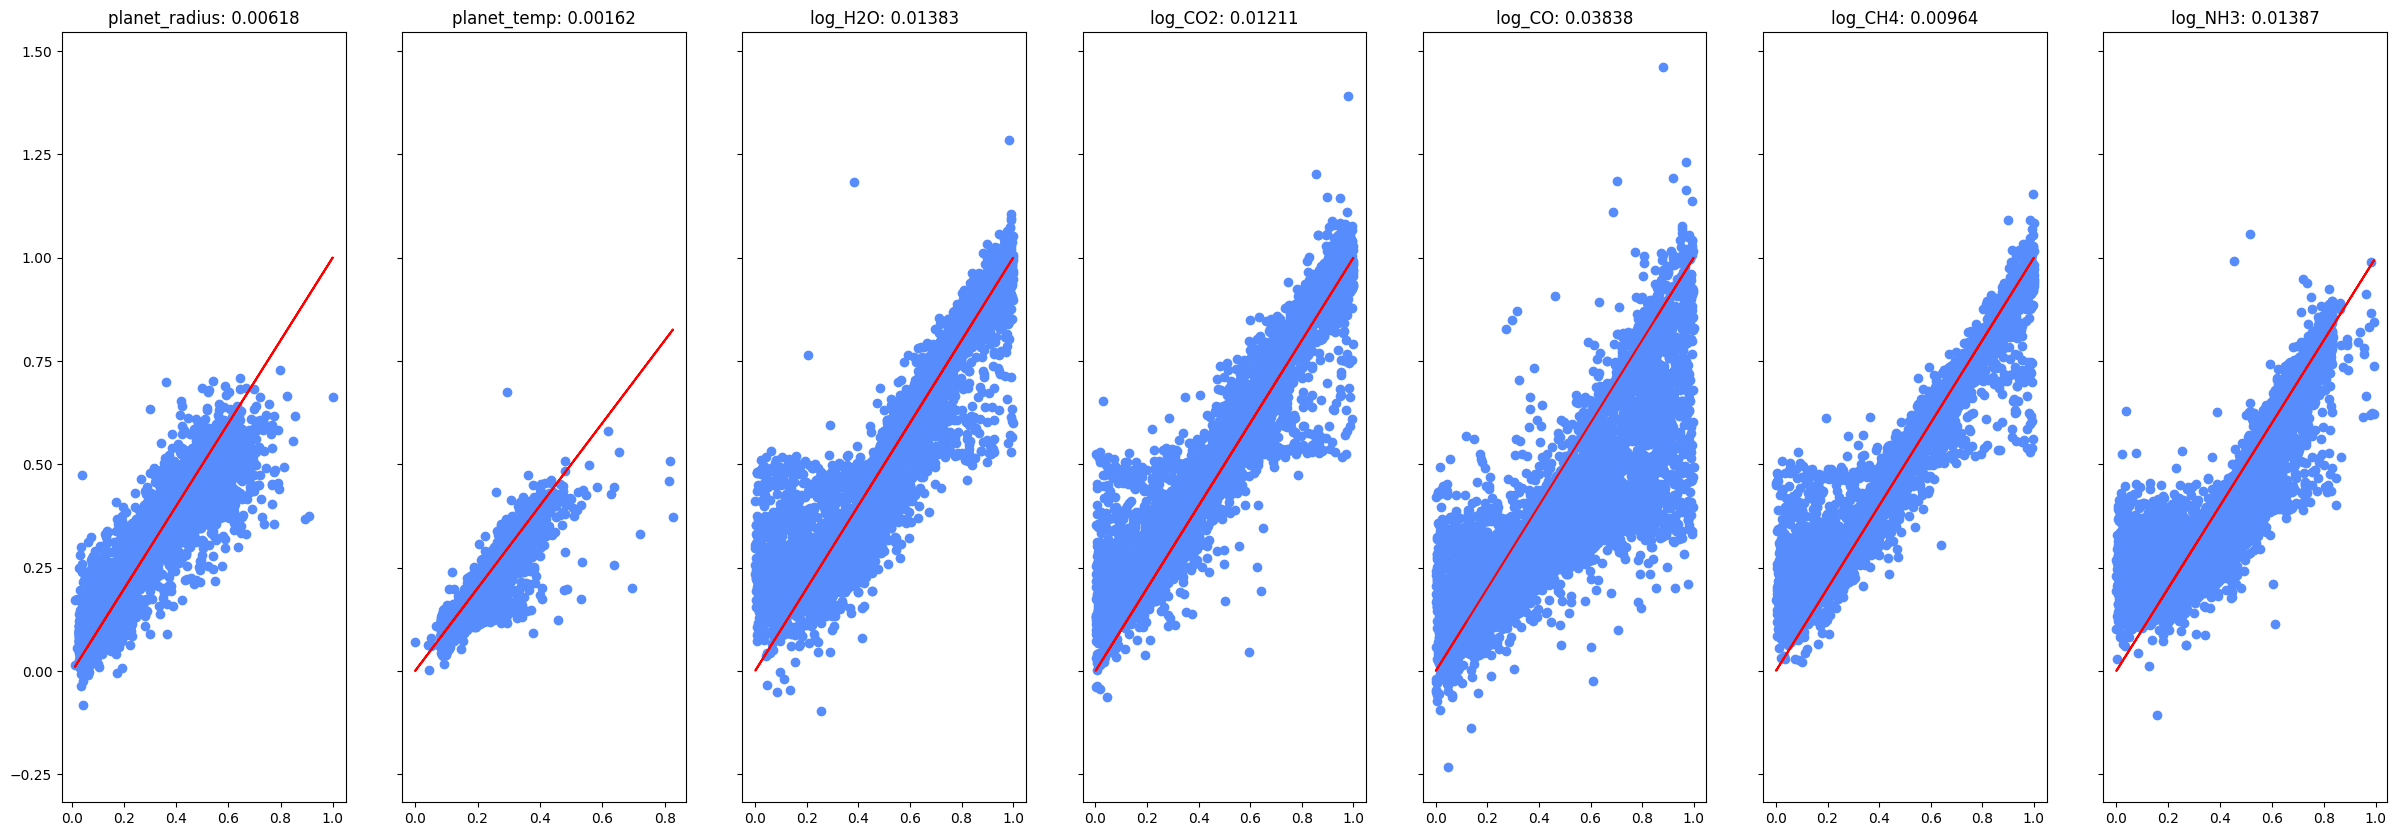

In [146]:
fig, ax = plt.subplots(1, n, figsize=(30,10), sharey=True)
for i in range(n):
    ax[i].scatter(y_test[:,i], y_pred[:,i])
    ax[i].plot(y_test[:,i], y_test[:,i], 'r')
    ax[i].set_title(f'{param_names[i]}: {np.round(quality[i], 5)}')

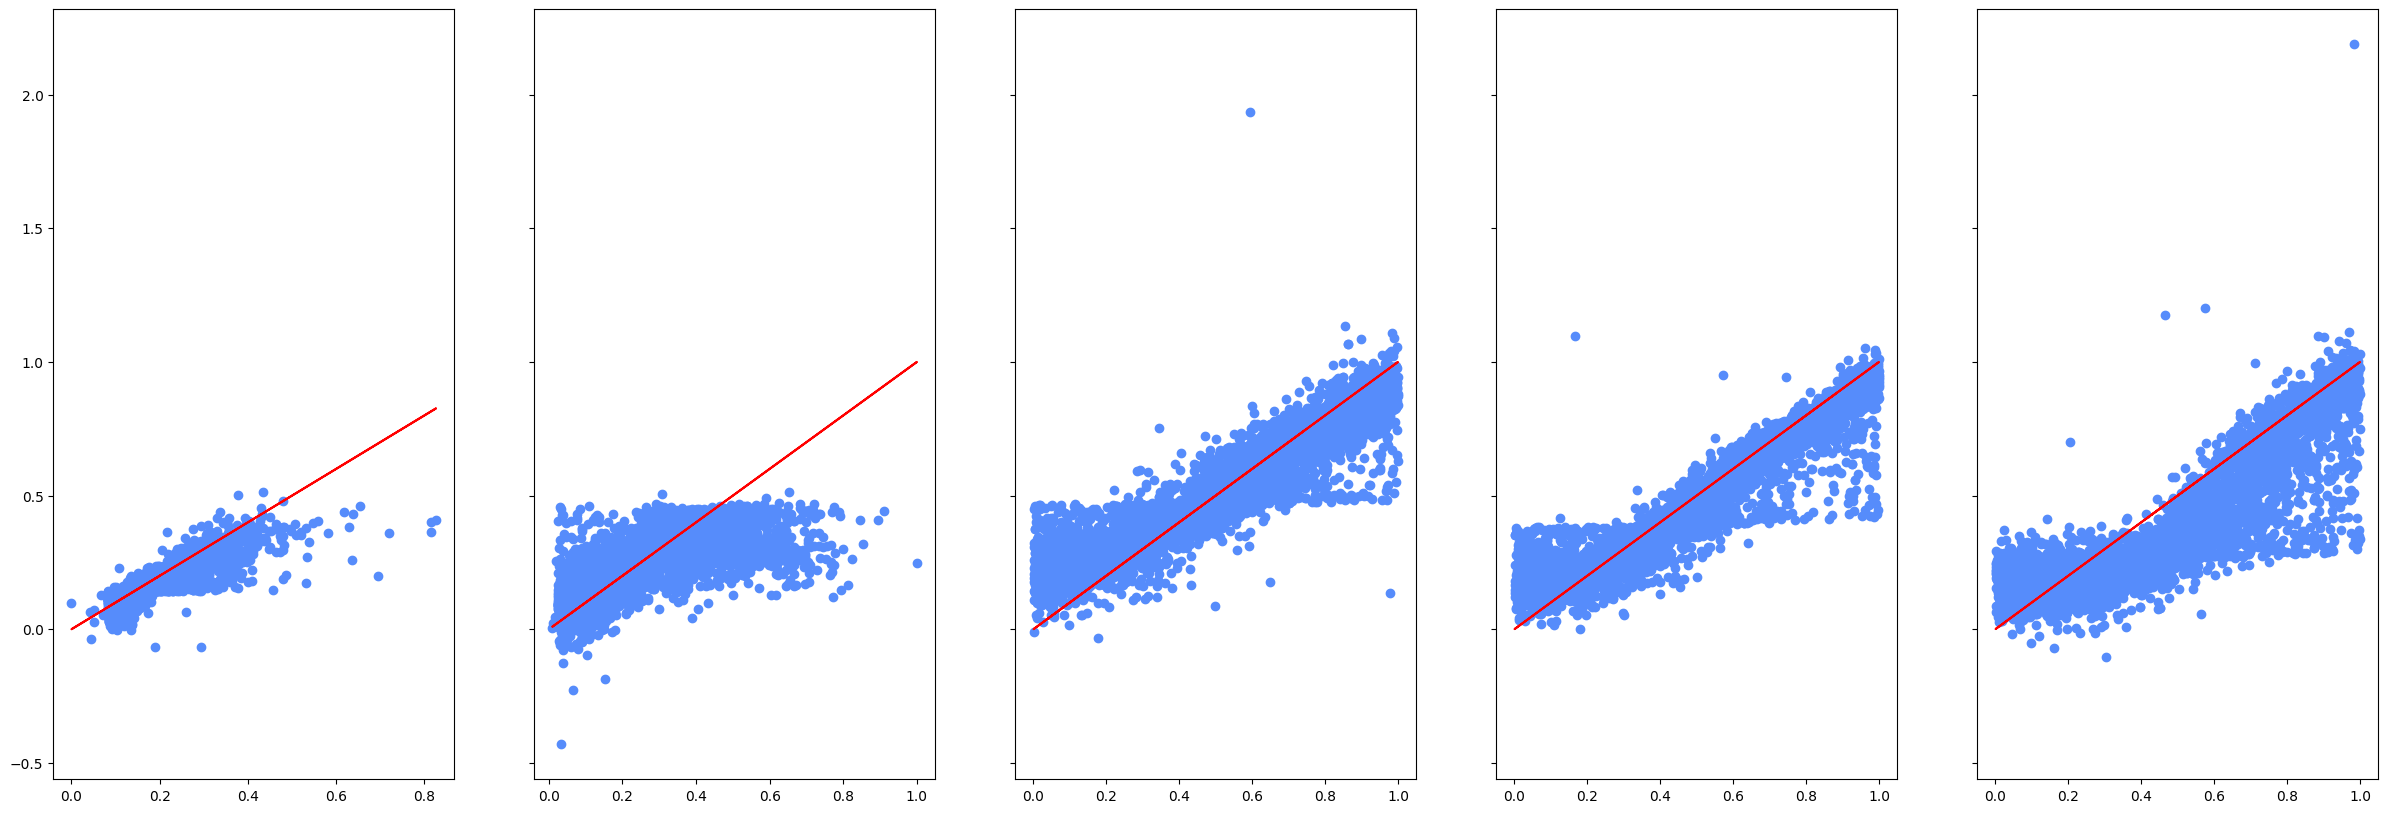

In [11]:
fig, ax = plt.subplots(1, 5, figsize=(30,10), sharey=True)
for i in range(n):
    ax[i].scatter(y_test[:,i], y_pred[:,i])
    ax[i].plot(y_test[:,i], y_test[:,i], 'r')

In [12]:
np.sum((y_pred-y_test)**2, axis=0)/y_test.shape[0]

array([0.0019619 , 0.01733009, 0.01463435, 0.01017508, 0.02922703])